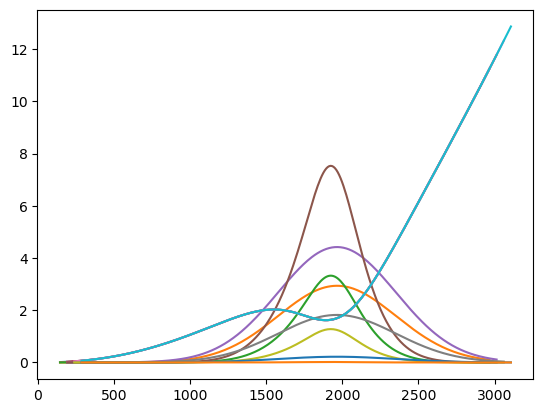

In [19]:
import astropy
import numpy as np
from pathlib import Path
from astropy.nddata import CCDData
from astropy.io import fits
import astropy.units as u
import matplotlib.pyplot as plt
import warnings
import glob


mass_star = 1.21
r_star = 1.357
teff_star = 6163
nu_max_sun_uHz = 3090.0
teff_sun_K = 5772.0
tau_sun_s = 250
max_rms_amplitude_sun = 2.1
delta_nu_sun = 135.1
epsilon = 1.55
    
def calc_maximum_rms_amplitude_radial(mass_star, teff_star):
    luminosity_ratio = (r_star**2) * (teff_star / teff_sun_K) ** 4
    power = -0.093
    t_red_star = 8907*(luminosity_ratio**power)
    delta_t = 1250
    dwarf_suppression_beta = 1 - np.exp((teff_star - t_red_star)/(delta_t))

    max_rms_amplitude_star = max_rms_amplitude_sun * dwarf_suppression_beta * luminosity_ratio *(mass_star**-1) * ((teff_star / teff_sun_K) ** (-2))   
    
    return max_rms_amplitude_star


l = np.linspace(0,3,4)
n = np.linspace(0,300,3001)
V = [1, 1.505, 0.620, 0.075]

    
def calc_nl_rms_amplitude_radial(mass_star, teff_star, n, l):
    
    nu_max = nu_max_sun_uHz * (mass_star / (r_star**2)) * (teff_star / teff_sun_K) ** (-0.5)
    #print(nu_max)
    delta_nu = delta_nu_sun * (mass_star**0.5) * (r_star**(-1.5))
    
    #nu_nl.append(delta_nu * (n + (l/2) + epsilon))
    
    nu_nl = delta_nu * (n + (l/2) + epsilon)
    
    envelope_FWHM = 0.66 * (nu_max ** 0.88)
    
    if teff_star > teff_sun_K:
        envelope_FWHM = envelope_FWHM * (1+6e-4 * (teff_star - teff_sun_K))
                
    width_envelope = envelope_FWHM / (2 * np.sqrt(2*np.log(2)))
        
    nl_rms_ampliude_star = V[l]*(((calc_maximum_rms_amplitude_radial(mass_star, teff_star) ** 2) * np.exp(-((nu_nl - nu_max)**2)/(2*(width_envelope**2))))**0.5)
    
    return nl_rms_ampliude_star, nu_nl


def visibility(amp, V):
    amp_visual = []
    for i in freq:
        i = i * V
        amp_visual.append(i)
    return amp_visual


"""for j in np.arange(len(l)):
    freq = []
    amp = []
    amplitudes_frequency = []
    for i in n:
        amplitudes_frequency.append(calc_nl_rms_amplitude_radial(mass_star, teff_star, i, j))
    
        freq.append(amplitudes_frequency[int(i)][1])
        amp.append(amplitudes_frequency[int(i)][0])
    
    
    
    all_freq.append(freq)
    all_amp.append(amp)
        
    plt.plot(freq,amp)"""




def width_parameter(mass_star, teff_star, a, b):
    nu_max = nu_max_sun_uHz * (mass_star / (r_star**2)) * (teff_star / teff_sun_K) ** (-0.5)
    P = (a*(nu_max/3090)) + b
    return P

alpha = width_parameter(mass_star, teff_star, 2.95, 0.39)
width_alpha = width_parameter(mass_star, teff_star, 3.08, 3.32)
delta_width_dip = width_parameter(mass_star, teff_star, -0.47, 0.62)
W_dip = width_parameter(mass_star, teff_star, 4637, -141)
nu_dip = width_parameter(mass_star, teff_star, 2984, 60)

def calc_width_nl(mass_star, teff_star, n, l):
    
    nu_max = nu_max_sun_uHz * (mass_star / (r_star**2)) * (teff_star / teff_sun_K) ** (-0.5)
    delta_nu = delta_nu_sun * (mass_star**0.5) * (r_star**(-1.5))
    nu_nl = delta_nu * (n + (l/2) + epsilon)
    
    Lnwidth = ((alpha * np.log(nu_nl/nu_max)) + np.log(width_alpha)) + (np.log(delta_width_dip)/(1 + (((2 * np.log(nu_nl/nu_dip))/(np.log(W_dip/nu_max)))**2)))
    width_nl = np.exp(Lnwidth)

    return width_nl, nu_nl

def lorentz(freq, centroid, scale): 
    #scale parameter is the half-width-half-maximum value of the Lorentz curve
    return (1/np.pi) * (scale / ((freq - centroid)**2 + scale**2))


all_nu = []
all_width = []
all_freq = []
all_amp = []


for j in np.arange(len(l)):
    nu = []
    width = []
    width_frequency = []
    
    freq = []
    amp = []
    amplitudes_frequency = []
    
    for i in n:
        width_frequency.append(calc_width_nl(mass_star, teff_star, i, j))
    
        nu.append(width_frequency[int(i)][1])
        width.append(width_frequency[int(i)][0])
    
        amplitudes_frequency.append(calc_nl_rms_amplitude_radial(mass_star, teff_star, i, j))
    
        freq.append(amplitudes_frequency[int(i)][1])
        amp.append(amplitudes_frequency[int(i)][0])
    
    all_nu.append(freq)
    all_width.append(amp)
    
    plt.plot(nu, width)

    all_freq.append(freq)
    all_amp.append(amp)
        
    plt.plot(freq,amp)
    
    spiky = (2 * (np.array(amp)*np.array(amp)))/(np.pi * np.array(width))
    plt.plot(freq, spiky)



    

